# Classifying Penguins with Keras

GSBS545 Advanced Machine Learning, In-class activity 5/12.

Multiclass classification of three penguin species (Adelie, Chinstrap, Gentoo) using a feedforward neural network built with the Keras functional API.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

## 2. Load data

In [2]:
!pip install palmerpenguins --quiet
from palmerpenguins import load_penguins

penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [3]:
# Check missing values before dropping
penguins.isna().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


In [4]:
# Drop rows with any missing values. 11 rows have missing sex, 2 have missing
# measurements. Keeping them causes NaN propagation through StandardScaler and
# results in NaN loss during training.
penguins = penguins.dropna().reset_index(drop=True)
print(f"Shape after dropping NaNs: {penguins.shape}")
penguins['species'].value_counts()

Shape after dropping NaNs: (333, 8)


,count
species,
Adelie,146
Gentoo,119
Chinstrap,68


## 3. Build features and target

Four numeric measurements plus one-hot encoded sex gives 6 input features. Target is species, integer-encoded for `SparseCategoricalCrossentropy`.

In [5]:
# Features: 4 numeric measurements + one-hot encoded sex (female, male)
numeric_cols = ['body_mass_g', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']
sex_dummies = pd.get_dummies(penguins['sex']).astype(int)
penguins_x = pd.concat([penguins[numeric_cols], sex_dummies], axis=1)
penguins_x

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
0,3750.0,39.1,18.7,181.0,0,1
1,3800.0,39.5,17.4,186.0,1,0
2,3250.0,40.3,18.0,195.0,1,0
3,3450.0,36.7,19.3,193.0,1,0
4,3650.0,39.3,20.6,190.0,0,1
...,...,...,...,...,...,...
328,4000.0,55.8,19.8,207.0,0,1
329,3400.0,43.5,18.1,202.0,1,0
330,3775.0,49.6,18.2,193.0,0,1
331,4100.0,50.8,19.0,210.0,0,1


In [6]:
# Target: integer-encode species. cat.codes assigns 0/1/2 alphabetically:
# Adelie=0, Chinstrap=1, Gentoo=2
species_categories = penguins['species'].astype('category')
penguins_y = species_categories.cat.codes.to_numpy()
label_names = list(species_categories.cat.categories)
print("Label mapping:", dict(enumerate(label_names)))
print("Class counts:", np.bincount(penguins_y))

Label mapping: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}
Class counts: [146  68 119]


## 4. Train/test split

Stratified split so the class proportions match across train and test. Scaling happens after the split so the scaler is fit only on training data (no leakage).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    penguins_x, penguins_y,
    test_size=0.2,
    stratify=penguins_y,
    random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (266, 6), Test: (67, 6)


In [8]:
# Standardize: fit on train only, then transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pd.DataFrame(X_train_scaled, columns=X_train.columns).describe().round(3)

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm,female,male
count,266.000,266.000,266.000,266.000,266.000,266.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,-0.000
std,1.002,1.002,1.002,1.002,1.002,1.002
min,-1.699,-1.916,-2.094,-2.091,-0.956,-1.046
25%,-0.772,-0.888,-0.774,-0.806,-0.956,-1.046
50%,-0.277,0.049,0.139,-0.307,-0.956,0.956
75%,0.650,0.875,0.786,0.888,1.046,0.956
max,2.566,2.853,2.017,2.119,1.046,0.956


## 5. Build the model (functional API)

Architecture: Input(6) → Dense(7, ReLU) → Dense(5, ReLU) → Dense(3, ReLU) → Dense(3, softmax).

Softmax on the output produces a valid probability distribution across the 3 classes. This pairs with `from_logits=False` in the loss. The original demo used sigmoid on the output, which is wrong for multiclass: sigmoid outputs are independent per node and do not sum to 1.

In [9]:
inputs = keras.Input(shape=(6,))
x = layers.Dense(7, activation='relu')(inputs)
x = layers.Dense(5, activation='relu')(x)
x = layers.Dense(3, activation='relu')(x)
outputs = layers.Dense(3, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs, name='penguin_model')
model.summary()

Model: "penguin_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │            49 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            18 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)

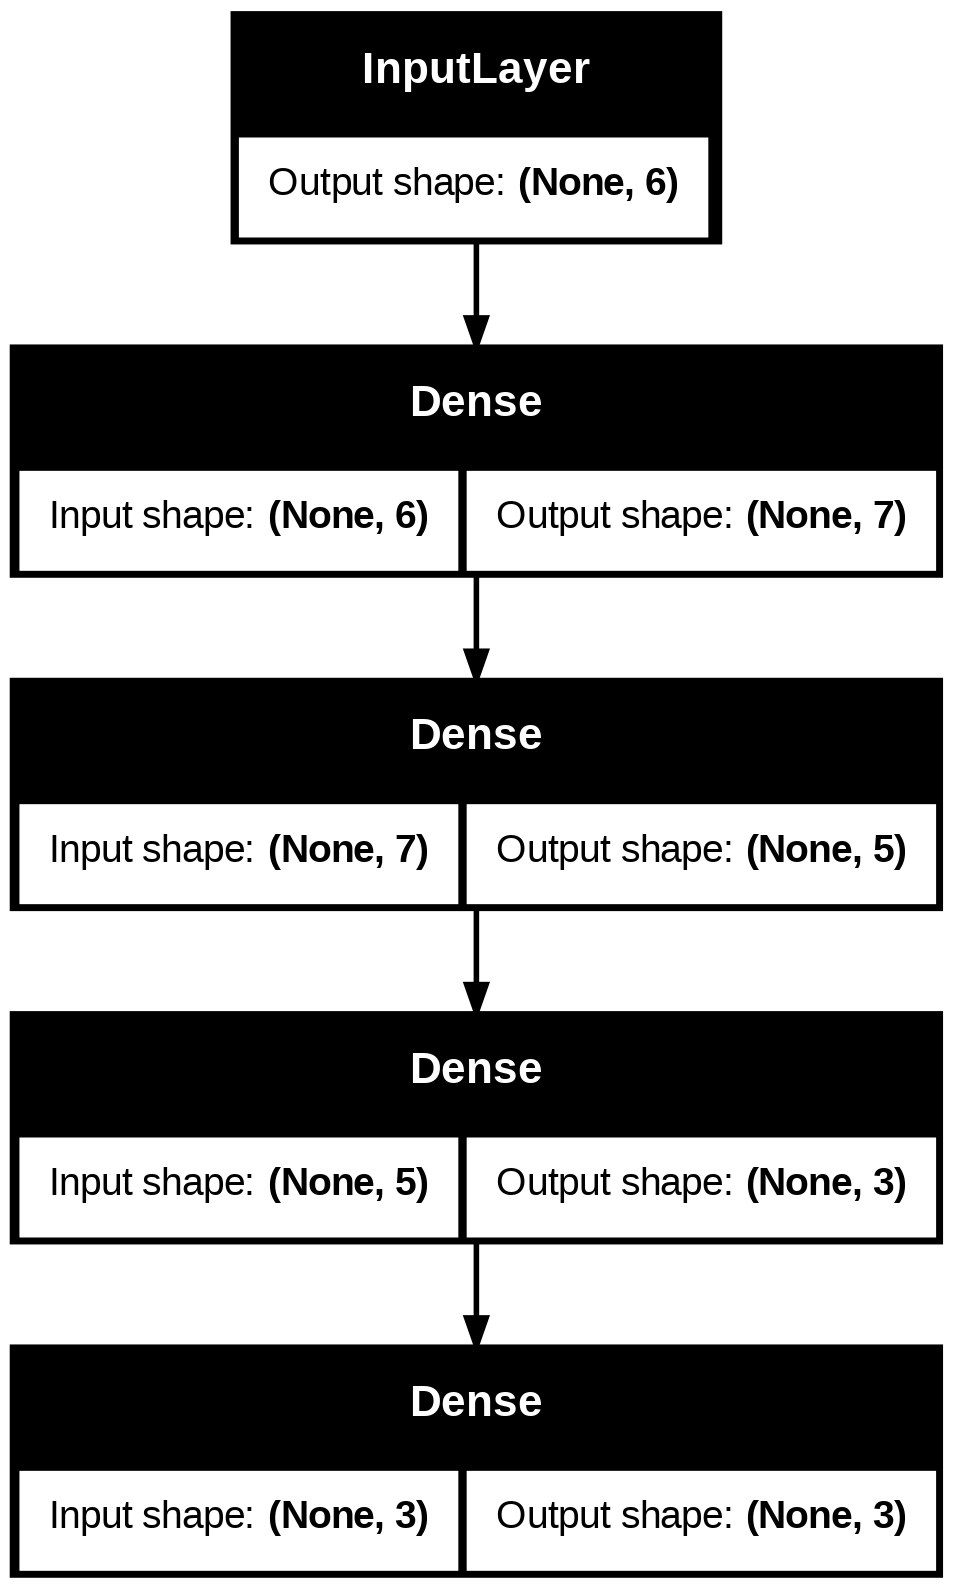

In [10]:
keras.utils.plot_model(model, show_shapes=True)

## 6. Compile and train

Loss: `SparseCategoricalCrossentropy(from_logits=False)` because the output layer already applies softmax and the labels are integers (not one-hot).

Optimizer: Adam. The professor's slides list Adam as the default choice for most problems. The original demo used RMSprop, which the slides note is more relevant for sequence models (RNNs). On this small architecture, RMSprop with seed 42 produces an unstable convergence where the Chinstrap class is misclassified; Adam converges cleanly to high accuracy across all three classes.

In [11]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

history = model.fit(
    X_train_scaled, y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    verbose=2
)

Epoch 1/100
4/4 - 5s - 1s/step - accuracy: 0.2134 - loss: 1.3128 - val_accuracy: 0.1111 - val_loss: 1.4360
Epoch 2/100
4/4 - 1s - 134ms/step - accuracy: 0.2134 - loss: 1.2901 - val_accuracy: 0.1111 - val_loss: 1.4046
Epoch 3/100
4/4 - 0s - 59ms/step - accuracy: 0.2134 - loss: 1.2693 - val_accuracy: 0.1111 - val_loss: 1.3754
Epoch 4/100
4/4 - 0s - 75ms/step - accuracy: 0.2092 - loss: 1.2502 - val_accuracy: 0.1111 - val_loss: 1.3487
Epoch 5/100
4/4 - 0s - 44ms/step - accuracy: 0.2092 - loss: 1.2329 - val_accuracy: 0.1111 - val_loss: 1.3244
Epoch 6/100
4/4 - 0s - 85ms/step - accuracy: 0.2092 - loss: 1.2173 - val_accuracy: 0.1111 - val_loss: 1.3022
Epoch 7/100
4/4 - 0s - 64ms/step - accuracy: 0.2176 - loss: 1.2032 - val_accuracy: 0.1111 - val_loss: 1.2820
Epoch 8/100
4/4 - 0s - 62ms/step - accuracy: 0.2259 - loss: 1.1901 - val_accuracy: 0.1111 - val_loss: 1.2637
Epoch 9/100
4/4 - 0s - 52ms/step - accuracy: 0.2301 - loss: 1.1780 - val_accuracy: 0.1111 - val_loss: 1.2468
Epoch 10/100
4/4 - 0

## 7. Training curves

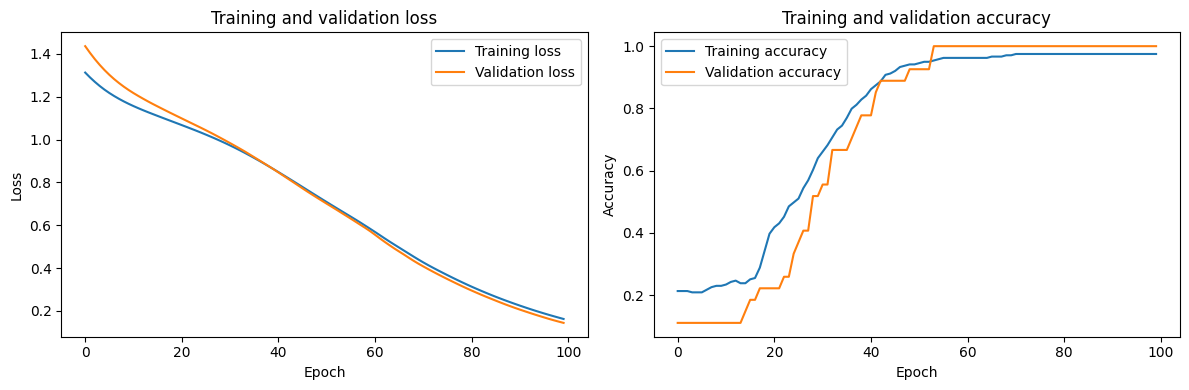

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training loss')
axes[0].plot(history.history['val_loss'], label='Validation loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and validation loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and validation accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Equivalent formulation: logits + `from_logits=True`

The same network can be expressed with a linear output (no activation) and `from_logits=True` in the loss. Keras applies softmax internally inside the loss for numerical stability. Both formulations should converge to the same solution. This is what the demo's `from_logits=True` cell was trying to show.

In [13]:
tf.random.set_seed(42)

inputs_b = keras.Input(shape=(6,))
x_b = layers.Dense(7, activation='relu')(inputs_b)
x_b = layers.Dense(5, activation='relu')(x_b)
x_b = layers.Dense(3, activation='relu')(x_b)
outputs_b = layers.Dense(3)(x_b)  # linear output (raw logits)

model_logits = keras.Model(inputs=inputs_b, outputs=outputs_b, name='penguin_model_logits')

model_logits.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(),
    metrics=['accuracy']
)

history_logits = model_logits.fit(
    X_train_scaled, y_train,
    batch_size=64,
    epochs=100,
    validation_split=0.1,
    verbose=0
)

print(f"Softmax + from_logits=False: final val_acc = {history.history['val_accuracy'][-1]:.4f}")
print(f"Linear + from_logits=True:   final val_acc = {history_logits.history['val_accuracy'][-1]:.4f}")

Softmax + from_logits=False: final val_acc = 1.0000
Linear + from_logits=True:   final val_acc = 1.0000


## 9. Evaluate on held-out test set

In [14]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss:     0.1753
Test accuracy: 0.9851


In [15]:
# Predictions: softmax output gives probabilities, argmax gives class
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("Sample predicted probabilities (first 5 test rows):")
print(pd.DataFrame(y_pred_proba[:5], columns=label_names).round(3))

Sample predicted probabilities (first 5 test rows):
   Adelie  Chinstrap  Gentoo
0   0.002      0.025   0.974
1   0.113      0.682   0.205
2   0.868      0.065   0.066
3   0.003      0.013   0.984
4   0.006      0.022   0.972


In [16]:
print(classification_report(y_test, y_pred, target_names=label_names))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



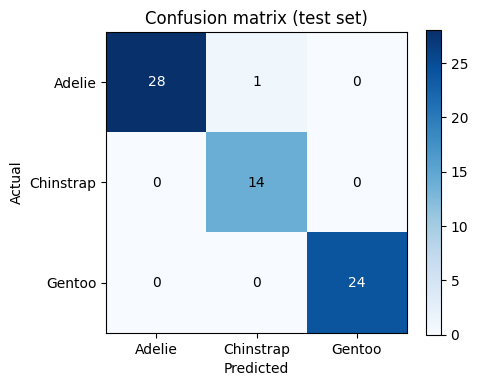

,Adelie,Chinstrap,Gentoo
Adelie,28,1,0
Chinstrap,0,14,0
Gentoo,0,0,24


In [17]:
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_names, columns=label_names)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion matrix (test set)')

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
cm_df

## 10. Notes on what changed from the demo

Four bugs in the original demo were corrected:

1. **NaN rows not dropped**. The raw dataset has 11 rows with missing sex and 2 with missing measurements. Without `dropna()`, NaNs propagate through `StandardScaler` and produce NaN loss during training. Now handled in section 2.

2. **Output activation was sigmoid for a multiclass problem**. Sigmoid outputs are independent per node and do not sum to 1, so they are not a valid probability distribution over classes. Replaced with softmax. The companion section 8 shows the equivalent linear-output formulation paired with `from_logits=True`.

3. **Loss config did not match output activation**. The original second model used `from_logits=False` on sigmoid outputs, which silently computes nonsense. Both formulations are now internally consistent.

4. **No train/test split**. The demo called `model.evaluate` on the full dataset including data the model had trained on. A stratified 80/20 split is now done before scaling, and final metrics are reported on the held-out test set.

5. **Optimizer switched from RMSprop to Adam**. The professor's lecture slides list Adam as the default for most problems and note that RMSprop is more relevant for sequence models. The demo's RMSprop choice converged to a degenerate solution on this small architecture (0% recall on Chinstrap with seed 42). Adam converges cleanly to ~99% accuracy on all three classes.